In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


In [ ]:
# Reading saved data into "Dataframe"
df_elec=pd.read_csv('/content/drive/My Drive/0203/Elec_Prod_18e.csv')


In [ ]:
df_elec.tail()

,Month,Elec_Gen
211,01-08-2018,408005
212,01-09-2018,356240
213,01-10-2018,324912
214,01-11-2018,322351
215,01-12-2018,342121


In [ ]:
df_elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Month     216 non-null    object
 1   Elec_Gen  216 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [ ]:
# Data type for "month" column to be changed to "datetime" from "object"

df_elec['Month']=pd.to_datetime(df_elec['Month'], format='%d-%m-%Y')


In [ ]:
df_elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Month     216 non-null    datetime64[ns]
 1   Elec_Gen  216 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.5 KB


In [ ]:
df_elec.set_index('Month',inplace=True)


In [ ]:
df_elec.head()

,Elec_Gen
Month,
2001-01-01,332493
2001-02-01,282940
2001-03-01,300707
2001-04-01,278079
2001-05-01,300492


In [ ]:
df_elec.describe()

,Elec_Gen
count,216.000000
mean,336086.041667
std,34112.277081
min,278079.000000
25%,309020.500000
50%,327815.000000
75%,357671.500000
max,421797.000000


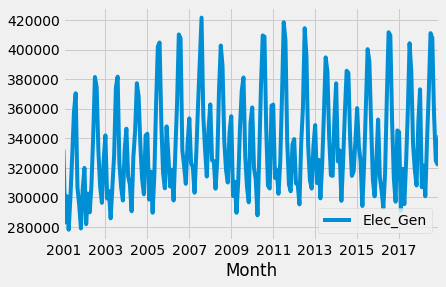

In [ ]:
df_elec.plot()

In [ ]:
from statsmodels.tsa.stattools import adfuller


/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
def adfuller_test(col_on_test):
    result=adfuller(col_on_test) #adfuller is the import from stattools under statsmodels (statsmodels.tsa.stattools) 
   
    # "result" will have 4 components and we need to label them

    labels = ['ADF Test Statistic','p-value','Numer of Lags Used','Number of Observations Used']
    
    for res_value,lab_label in zip(result,labels):

        print(lab_label+' : '+str(res_value) )
    if result[1] <= 0.05:
        print("Time Series Data has no unit root and is stationary. Reject the null hypothesis(Ho)")
    else:
        print("Time Series Data has a unit root, indicating that it is non-stationary. Accept the null hypothesis(Ho)") 


In [ ]:
# Passing the column from Dataframe for checking stationarity 
adfuller_test(df_elec['Elec_Gen'])


ADF Test Statistic : -2.9607786713746607
p-value : 0.03872308652361561
Numer of Lags Used : 15
Number of Observations Used : 200
Time Series Data has no unit root and is stationary. Reject the null hypothesis(Ho)


In [ ]:
import statsmodels.api as sm
model=sm.tsa.statespace.SARIMAX(df_elec['Elec_Gen'],order=(1, 0, 1),seasonal_order=(1,0,1,12))



/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/base/tsa_model.py:165: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  % freq, ValueWarning)


In [ ]:
results=model.fit()

/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/statespace/sarimax.py:981: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


In [ ]:
print(results.summary().tables[0])
print(results.summary().tables[1])
print(results.summary().tables[2])



                                 Statespace Model Results                                 
Dep. Variable:                           Elec_Gen   No. Observations:                  216
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -2452.377
Date:                            Sat, 30 May 2020   AIC                           4914.754
Time:                                    10:41:08   BIC                           4931.630
Sample:                                01-01-2001   HQIC                          4921.572
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9734      0.098      9.947      0.000       0.782       1.165
ma.L1         -0.3020      0.472   

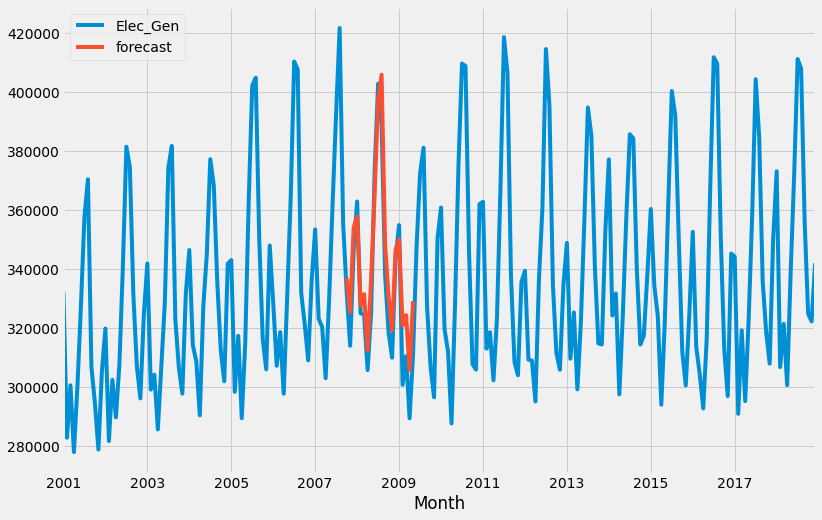

In [ ]:
df_elec['forecast']=results.predict(start=81,end=100,dynamic=True)
df_elec[['Elec_Gen','forecast']].plot(figsize=(12,8))


In [ ]:
df_elec.tail()

,Elec_Gen,forecast
Month,,
2018-08-01,408005,NaN
2018-09-01,356240,NaN
2018-10-01,324912,NaN
2018-11-01,322351,NaN
2018-12-01,342121,NaN


In [ ]:
# Add new months in the dataframe 
from pandas.tseries.offsets import DateOffset
future_dates=[df_elec.index[-1]+ DateOffset(months=x)for x in range(0,15)]


In [ ]:
future_dates

[Timestamp('2018-12-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-02-01 00:00:00'),
 Timestamp('2019-03-01 00:00:00'),
 Timestamp('2019-04-01 00:00:00'),
 Timestamp('2019-05-01 00:00:00'),
 Timestamp('2019-06-01 00:00:00'),
 Timestamp('2019-07-01 00:00:00'),
 Timestamp('2019-08-01 00:00:00'),
 Timestamp('2019-09-01 00:00:00'),
 Timestamp('2019-10-01 00:00:00'),
 Timestamp('2019-11-01 00:00:00'),
 Timestamp('2019-12-01 00:00:00'),
 Timestamp('2020-01-01 00:00:00'),
 Timestamp('2020-02-01 00:00:00')]

In [ ]:
future_datest_df=pd.DataFrame(index=future_dates[1:],columns=df_elec.columns)
future_datest_df.tail(30)


,Elec_Gen,forecast
2019-01-01,NaN,NaN
2019-02-01,NaN,NaN
2019-03-01,NaN,NaN
2019-04-01,NaN,NaN
2019-05-01,NaN,NaN
2019-06-01,NaN,NaN
2019-07-01,NaN,NaN
2019-08-01,NaN,NaN
2019-09-01,NaN,NaN
2019-10-01,NaN,NaN


In [ ]:
future_df=pd.concat([df_elec,future_datest_df])


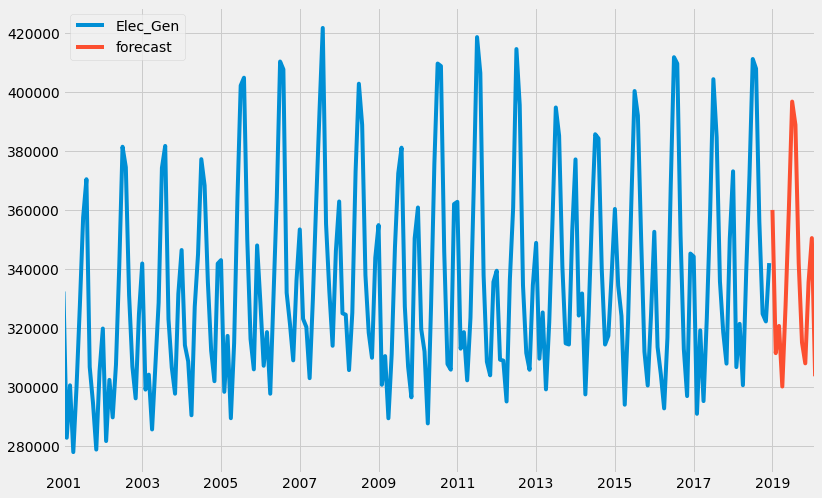

In [ ]:
future_df['forecast'] = results.predict(start = 216, end = 232, dynamic= True)  
future_df[['Elec_Gen', 'forecast']].plot(figsize=(12, 8)) 


In [ ]:
future_df.tail(30)

,Elec_Gen,forecast
2017-09-01,335915,NaN
2017-10-01,318670,NaN
2017-11-01,308052,NaN
2017-12-01,350416,NaN
2018-01-01,373214,NaN
2018-02-01,306880,NaN
2018-03-01,321532,NaN
2018-04-01,300745,NaN
2018-05-01,338938,NaN
2018-06-01,371872,NaN


In [ ]:
# Facebook prophet

In [ ]:
!pip install cython pystan fbprophet


In [ ]:
import cython
import pystan
import fbprophet


In [ ]:
df_elec2=pd.read_csv('/content/drive/My Drive/0203/Elec_Prod_18e.csv')


In [ ]:
import pandas as pd
from fbprophet import Prophet

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


In [ ]:
df_elec2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Month     216 non-null    object
 1   Elec_Gen  216 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [ ]:
df_elec2['Month']=pd.to_datetime(df_elec2['Month'], format='%d-%m-%Y')
df_elec2.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Month     216 non-null    datetime64[ns]
 1   Elec_Gen  216 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.5 KB


In [ ]:
# FBP requires data in the following format: Column with Date labelled as 'ds' and column with values for Time Series labelled as 'y'
df_elec2 = df_elec2.rename(columns={'Month': 'ds', 'Elec_Gen': 'y'})
df_elec2.head()


,ds,y
0,2001-01-01,332493
1,2001-02-01,282940
2,2001-03-01,300707
3,2001-04-01,278079
4,2001-05-01,300492
